In [68]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, Dropout
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [21]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [35]:
nsamples, nx, ny = x_train.shape
x_train_d2 = x_train.reshape((nsamples, nx * ny))
x_train_normed = StandardScaler().fit_transform(x_train_d2)

nsamples, nx, ny = x_test.shape
x_test_d2 = x_test.reshape((nsamples, nx * ny))
x_test_normed = StandardScaler().fit_transform(x_test_d2)

In [51]:
y_train_ohe = pd.get_dummies(y_train).as_matrix()
y_test_ohe = pd.get_dummies(y_test).as_matrix()

Baseline model

In [60]:
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
print(nn_model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 32)                25120     
_________________________________________________________________
dense_13 (Dense)             (None, 32)                1056      
_________________________________________________________________
output (Dense)               (None, 10)                330       
Total params: 26,506
Trainable params: 26,506
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.7474 - acc: 0.7875 - val_loss: 0.3449 - val_acc: 0.9005
Epoch 2/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.3018 - acc: 0.9123 - val_loss: 0.2652 - val_acc: 0.9236
Epoch 3/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2428 - acc: 0.9281 - val_loss: 0.2324 - val_acc: 0.9327
Epoch 4/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2112 - acc: 0.9377 - val_loss: 0.2118 - val_acc: 0.9371
Epoch 5/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1897 - acc: 0.9438 - val_loss: 0.1977 - val_acc: 0.9414
Epoch 6/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1737 - acc: 0.9483 - val_loss: 0.1879 - val_acc: 0.9451
Epoch 7/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1607 - acc: 0.9523 - val_loss: 0.1789 - val_acc

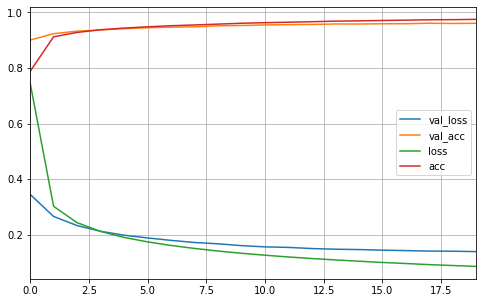

CPU times: user 1min 4s, sys: 8.84 s, total: 1min 13s
Wall time: 45.8 s


In [54]:
%%time
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [44]:
def save_keras_model(model, history, file_name):
    model_json = model.to_json()
    with open("./models/{}.json".format(file_name), 'w') as json_file:
        json_file.write(model_json)
    model.save_weights("./models/{}.h5".format(file_name))
    with open('./models/{}.history'.format(file_name), 'wb') as file_history:
        pickle.dump(history.history, file_history)
    print("model saved")
save_keras_model(nn_model, history, 'base_model')

model saved


Model with 64 neurons

In [58]:
model_sequences = [
    keras.layers.Dense(units=64, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=64, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_64 = keras.models.Sequential(model_sequences)
print(nn_model_64.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_10 (Dense)             (None, 64)                50240     
_________________________________________________________________
dense_11 (Dense)             (None, 64)                4160      
_________________________________________________________________
output (Dense)               (None, 10)                650       
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 57us/step - loss: 0.7306 - acc: 0.7913 - val_loss: 0.3328 - val_acc: 0.9039
Epoch 2/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.2856 - acc: 0.9179 - val_loss: 0.2483 - val_acc: 0.9271
Epoch 3/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.2224 - acc: 0.9351 - val_loss: 0.2116 - val_acc: 0.9382
Epoch 4/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.1888 - acc: 0.9440 - val_loss: 0.1919 - val_acc: 0.9436
Epoch 5/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.1660 - acc: 0.9503 - val_loss: 0.1778 - val_acc: 0.9487
Epoch 6/20
60000/60000 [==============================] - 2s 41us/step - loss: 0.1493 - acc: 0.9564 - val_loss: 0.1669 - val_acc: 0.9523
Epoch 7/20
60000/60000 [==============================] - 2s 41us/step - loss: 0.1361 - acc: 0.9600 - val_loss: 0.1587 - val_acc

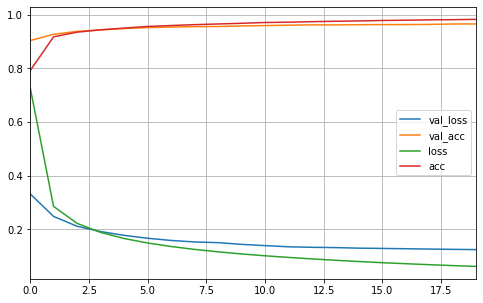

CPU times: user 1min 16s, sys: 10.4 s, total: 1min 26s
Wall time: 51 s


In [59]:
%%time
nn_model_64.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_64.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_64, history, 'model_64_n')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Models with different learning rates

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 51us/step - loss: 2.7551 - acc: 0.1054 - val_loss: 2.7427 - val_acc: 0.1061
Epoch 2/20
60000/60000 [==============================] - 2s 36us/step - loss: 2.7171 - acc: 0.1099 - val_loss: 2.7061 - val_acc: 0.1103
Epoch 3/20
60000/60000 [==============================] - 2s 37us/step - loss: 2.6811 - acc: 0.1154 - val_loss: 2.6714 - val_acc: 0.1152
Epoch 4/20
60000/60000 [==============================] - 2s 37us/step - loss: 2.6470 - acc: 0.1205 - val_loss: 2.6385 - val_acc: 0.1225
Epoch 5/20
60000/60000 [==============================] - 3s 45us/step - loss: 2.6146 - acc: 0.1270 - val_loss: 2.6072 - val_acc: 0.1283
Epoch 6/20
60000/60000 [==============================] - 2s 38us/step - loss: 2.5837 - acc: 0.1332 - val_loss: 2.5772 - val_acc: 0.1358
Epoch 7/20
60000/60000 [==============================] - 2s 38us/step - loss: 2.5542 - acc: 0.1397 - val_loss: 2.5487 - val_acc

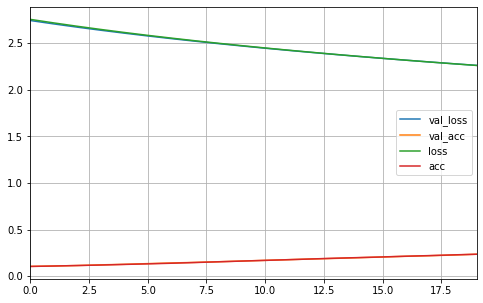

CPU times: user 1min 8s, sys: 9.67 s, total: 1min 18s
Wall time: 47.5 s


In [66]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_lr = keras.models.Sequential(model_sequences)
sgd = SGD(lr=0.000001, momentum=0.9)
nn_model_lr.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_lr.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_lr, history, 'model_lr')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with batch size 32

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 4s 69us/step - loss: 0.5668 - acc: 0.8365 - val_loss: 0.2792 - val_acc: 0.9148
Epoch 2/20
60000/60000 [==============================] - 4s 61us/step - loss: 0.2404 - acc: 0.9287 - val_loss: 0.2181 - val_acc: 0.9351
Epoch 3/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1919 - acc: 0.9427 - val_loss: 0.1942 - val_acc: 0.9410
Epoch 4/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1651 - acc: 0.9514 - val_loss: 0.1799 - val_acc: 0.9466
Epoch 5/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1465 - acc: 0.9572 - val_loss: 0.1711 - val_acc: 0.9500
Epoch 6/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1330 - acc: 0.9608 - val_loss: 0.1595 - val_acc: 0.9534
Epoch 7/20
60000/60000 [==============================] - 4s 61us/step - loss: 0.1216 - acc: 0.9639 - val_loss: 0.1558 - val_acc

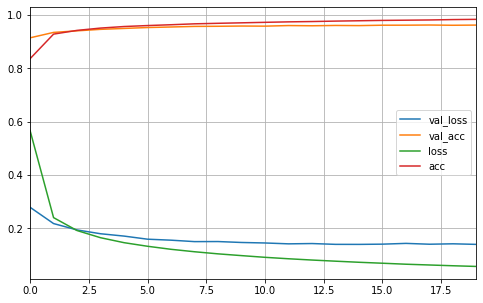

CPU times: user 1min 47s, sys: 16.6 s, total: 2min 4s
Wall time: 1min 15s


In [64]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_bs_32 = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=32, verbose=1)
# save_keras_model(nn_model, history, 'model_64_n')
pd.DataFrame(history_bs_32.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with batch size 128

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 56us/step - loss: 1.0841 - acc: 0.6896 - val_loss: 0.5117 - val_acc: 0.8577
Epoch 2/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.4331 - acc: 0.8779 - val_loss: 0.3595 - val_acc: 0.8952
Epoch 3/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.3334 - acc: 0.9035 - val_loss: 0.3063 - val_acc: 0.9091
Epoch 4/20
60000/60000 [==============================] - 2s 30us/step - loss: 0.2860 - acc: 0.9172 - val_loss: 0.2741 - val_acc: 0.9196
Epoch 5/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2560 - acc: 0.9252 - val_loss: 0.2529 - val_acc: 0.9266
Epoch 6/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.2344 - acc: 0.9315 - val_loss: 0.2376 - val_acc: 0.9301
Epoch 7/20
60000/60000 [==============================] - 2s 33us/step - loss: 0.2174 - acc: 0.9368 - val_loss: 0.2249 - val_acc

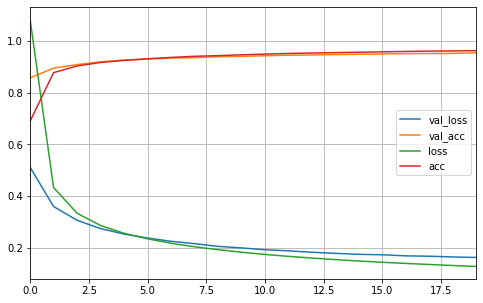

CPU times: user 51 s, sys: 7.48 s, total: 58.5 s
Wall time: 41 s


In [73]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_bs_128 = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=128, verbose=1)
# save_keras_model(nn_model, history, 'model_64_n')
pd.DataFrame(history_bs_128.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with another hidden layer

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 4s 64us/step - loss: 0.8933 - acc: 0.7352 - val_loss: 0.3632 - val_acc: 0.8967
Epoch 2/20
60000/60000 [==============================] - 2s 41us/step - loss: 0.3109 - acc: 0.9091 - val_loss: 0.2653 - val_acc: 0.9228
Epoch 3/20
60000/60000 [==============================] - 2s 39us/step - loss: 0.2410 - acc: 0.9287 - val_loss: 0.2276 - val_acc: 0.9342
Epoch 4/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.2058 - acc: 0.9384 - val_loss: 0.2071 - val_acc: 0.9395
Epoch 5/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.1826 - acc: 0.9462 - val_loss: 0.1951 - val_acc: 0.9429
Epoch 6/20
60000/60000 [==============================] - 3s 43us/step - loss: 0.1657 - acc: 0.9512 - val_loss: 0.1830 - val_acc: 0.9440
Epoch 7/20
60000/60000 [==============================] - 3s 51us/step - loss: 0.1525 - acc: 0.9553 - val_loss: 0.1744 - val_acc

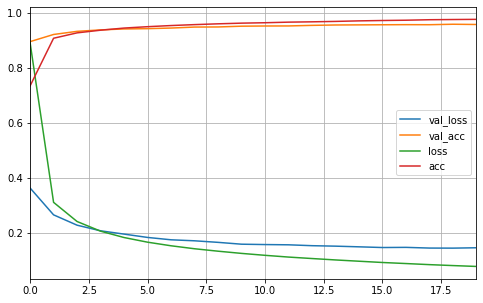

CPU times: user 1min 15s, sys: 11.5 s, total: 1min 27s
Wall time: 53.2 s


In [67]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_3_layers = keras.models.Sequential(model_sequences)
nn_model_3_layers.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_3_layers.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_3_layers, history, 'model_3_layers')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with 128, 128, 10 and dropout

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 5s 77us/step - loss: 1.5895 - acc: 0.4944 - val_loss: 0.5501 - val_acc: 0.8525
Epoch 2/20
60000/60000 [==============================] - 4s 65us/step - loss: 0.8836 - acc: 0.7168 - val_loss: 0.4063 - val_acc: 0.8873
Epoch 3/20
60000/60000 [==============================] - 4s 64us/step - loss: 0.7536 - acc: 0.7659 - val_loss: 0.3654 - val_acc: 0.9010
Epoch 4/20
60000/60000 [==============================] - 4s 64us/step - loss: 0.6825 - acc: 0.7900 - val_loss: 0.3336 - val_acc: 0.9060
Epoch 5/20
60000/60000 [==============================] - 4s 65us/step - loss: 0.6334 - acc: 0.8072 - val_loss: 0.3159 - val_acc: 0.9107
Epoch 6/20
60000/60000 [==============================] - 4s 65us/step - loss: 0.6016 - acc: 0.8142 - val_loss: 0.2947 - val_acc: 0.9164
Epoch 7/20
60000/60000 [==============================] - 4s 65us/step - loss: 0.5715 - acc: 0.8253 - val_loss: 0.2781 - val_acc

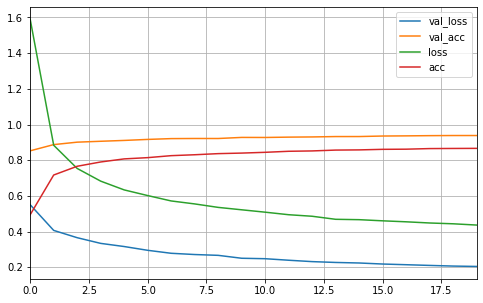

CPU times: user 2min 29s, sys: 16.4 s, total: 2min 45s
Wall time: 1min 22s


In [71]:
%%time
model_sequences = [
    keras.layers.Dropout(rate=0.5, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dropout(rate=0.5, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dropout(rate=0.5, input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_dropout = keras.models.Sequential(model_sequences)
nn_model_dropout.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_dropout.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_dropout, history, 'model_128_dropout')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 11s 184us/step - loss: 0.5237 - acc: 0.8476 - val_loss: 0.2403 - val_acc: 0.9308
Epoch 2/20
60000/60000 [==============================] - 8s 132us/step - loss: 0.2146 - acc: 0.9370 - val_loss: 0.1802 - val_acc: 0.9469
Epoch 3/20
60000/60000 [==============================] - 8s 132us/step - loss: 0.1607 - acc: 0.9523 - val_loss: 0.1592 - val_acc: 0.9547
Epoch 4/20
60000/60000 [==============================] - 8s 140us/step - loss: 0.1303 - acc: 0.9608 - val_loss: 0.1444 - val_acc: 0.9598
Epoch 5/20
60000/60000 [==============================] - 9s 144us/step - loss: 0.1096 - acc: 0.9677 - val_loss: 0.1373 - val_acc: 0.9631
Epoch 6/20
60000/60000 [==============================] - 9s 150us/step - loss: 0.0940 - acc: 0.9728 - val_loss: 0.1315 - val_acc: 0.9654
Epoch 7/20
60000/60000 [==============================] - 8s 131us/step - loss: 0.0825 - acc: 0.9760 - val_loss: 0.1224 -

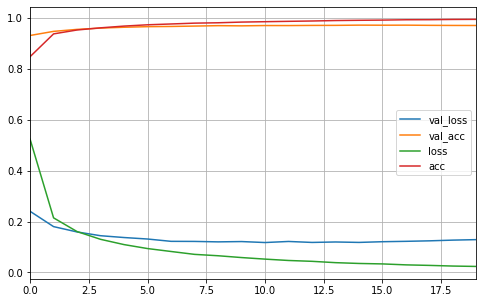

CPU times: user 3min 36s, sys: 26.7 s, total: 4min 2s
Wall time: 2min 44s


In [83]:
%%time
model_sequences = [
    #keras.layers.Dropout(rate=0.5, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
    #keras.layers.Dropout(rate=0.1, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dropout(rate=0.1, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_dropout = keras.models.Sequential(model_sequences)
nn_model_dropout.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_dropout.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=32, verbose=1)
save_keras_model(nn_model_dropout, history, 'model_128_dropout')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()